In [1]:
# load data
import numpy as np
lfp_path = r"F:\GitHub\rippl-AI\allen_data\lfp_use_754312389_756781561.npy"
time_path = r"F:\GitHub\rippl-AI\allen_data\lfp_use_time_754312389_756781561.npy"
speed_path = r"F:\GitHub\rippl-AI\allen_data\lfp_use_speed_754312389_756781561.npy"
LFPs = np.load(lfp_path)  # Load LFP data from .npy file
time = np.load(time_path)  # Load time data from .npy file
speed = np.load(speed_path)

# time = np.arange(0, 10, 0.001)  # 10 seconds at 1000 Hz
# LFPs = np.random.randn(len(time), 4)  # 4 channels of LFP data
# speed = np.abs(np.random.randn(len(time)))  # Animal speed
sampling_frequency = 1250  # Hz

FileNotFoundError: [Errno 2] No such file or directory: 'F:\\GitHub\\rippl-AI\\allen_data\\lfp_use_754312389_756781561.npy'

In [3]:
from ripple_detection import Kay_ripple_detector

# Detect ripples
ripple_times = Kay_ripple_detector(
    time, LFPs, speed, sampling_frequency,
    speed_threshold=4.0,        # cm/s
    minimum_duration=0.015,     # seconds
    zscore_threshold=2.0
)

print(ripple_times)

NameError: name 'time' is not defined

In [ ]:
from ripple_detection import Karlsson_ripple_detector,filter_ripple_band

# Detect ripples with custom parameters
ripples = Karlsson_ripple_detector(
    time, LFPs[:,4:5], speed, sampling_frequency,
    speed_threshold=4.0,
    minimum_duration=0.015,
    zscore_threshold=3.0,
    smoothing_sigma=0.004,
    close_ripple_threshold=0.0
)

# Access detailed statistics
print(f"Detected {len(ripples)} ripple events")
print(f"Mean duration: {ripples['duration'].mean():.3f} seconds")
print(f"Mean z-score: {ripples['mean_zscore'].mean():.2f}")

NameError: name 'LFPs' is not defined

In [ ]:
import load_fcn
import os


path=os.path.join('Downloaded_data','Dlx1','figshare_14959449')

sf, expName, ref_channels, dead_channels = load_fcn.load_info(path)
channels_map = load_fcn.load_channels_map(path)

# Reformat channels into correct values
channels, shanks, ref_channels = load_fcn.reformat_channels(channels_map, ref_channels)
# Read .dat
print('Channel map value: ',channels)
LFPs = load_fcn.load_raw_data(path, expName, channels, verbose=True)
print('Sampling frequency: ', sf)
print('Shape of the original data',LFPs.shape)
print(channels_map)

Channel map value:  [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]
Downloaded_data\Dlx1\figshare_14959449/lfp_Dlx1-2021-02-12_12-46-54.dat
fileStart  0
fileStop  490242048
nSamples  245121024
nSamplesPerChannel  30640128
nSamplesPerChunk  10000
size data  30640128
Sampling frequency:  30000
Shape of the original data (30640128, 8)
[[1 1 2]
 [2 1 2]
 [3 1 2]
 [4 1 2]
 [5 1 2]
 [6 1 2]
 [7 1 2]
 [8 1 2]]


In [6]:
from ripple_detection import Karlsson_ripple_detector,filter_ripple_band
# for the parida lab data, I might need to make fake timestamps and speed
speed = np.zeros(LFPs.shape[0])
time = np.arange(LFPs.shape[0]) / sf
sampling_frequency = sf

filtered_LFPs = filter_ripple_band(LFPs, sampling_frequency)
# Detect ripples with custom parameters
ripples = Karlsson_ripple_detector(
    time, filtered_LFPs[:,4:5], speed, sampling_frequency,
    speed_threshold=4.0,
    minimum_duration=0.015,
    zscore_threshold=3.0,
    smoothing_sigma=0.004,
    close_ripple_threshold=0.0
)

# Access detailed statistics
print(f"Detected {len(ripples)} ripple events")
print(f"Mean duration: {ripples['duration'].mean():.3f} seconds")
print(f"Mean z-score: {ripples['mean_zscore'].mean():.2f}")

C:\Users\lilytong\AppData\Local\Temp\ipykernel_28268\1076084051.py:7: UserWarning: The pre-computed ripple filter is optimized for 1500.0 Hz sampling.
Your data: 30000 Hz. Results may be suboptimal.
For best results, use ripple_bandpass_filter(30000) to generate a custom filter.
  filtered_LFPs = filter_ripple_band(LFPs, sampling_frequency)
d:\miniconda3\envs\ripple_detection\lib\site-packages\numpy\_core\numeric.py:442: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(res, fill_value, casting='unsafe')


Detected 243 ripple events
Mean duration: 0.093 seconds
Mean z-score: 2.44


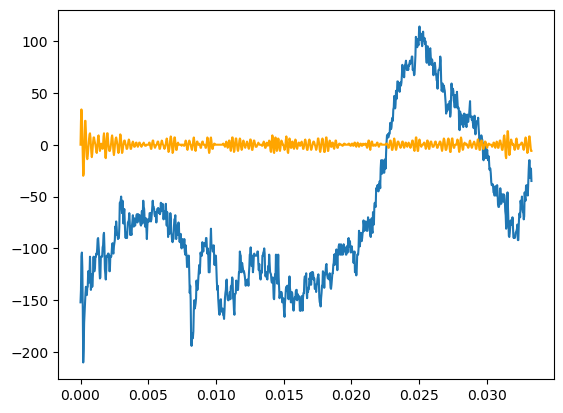

In [10]:
import matplotlib.pyplot as plt
plt.plot(time[:1000], LFPs[:1000,4], label='Raw LFP')
plt.plot(time[:1000], filtered_LFPs[:1000,4], label='Filtered LFP', color='orange')